# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
import random
from sklearn_extra.cluster import KMedoids
import skfuzzy as fuzz
from skfuzzy import control as ctrl
np.random.seed(42)
random.seed(42)
from scipy.spatial.distance import cdist

# Load Data

In [2]:
df = pd.read_csv("mental_health_burnout_tech_2026.csv")
df = df.head(4000)

# EDA

In [3]:
# Shape
print("Dataset Shape:", df.shape)
df.info()
df.head()

Dataset Shape: (4000, 36)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  4000 non-null   int64  
 1   age                          4000 non-null   int64  
 2   gender                       4000 non-null   str    
 3   country                      4000 non-null   str    
 4   job_role                     4000 non-null   str    
 5   seniority_level              4000 non-null   str    
 6   years_experience             4000 non-null   int64  
 7   years_at_company             4000 non-null   float64
 8   company_size                 4000 non-null   str    
 9   industry                     4000 non-null   str    
 10  work_mode                    4000 non-null   str    
 11  salary_usd                   4000 non-null   int64  
 12  work_hours_per_week          4000 non-null   int64  
 13  mee

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


In [4]:
print('Number of unique values in each column:')
print(df.nunique())
df.duplicated().sum()

Number of unique values in each column:
employee_id                    4000
age                              32
gender                            4
country                          10
job_role                         12
seniority_level                   6
years_experience                 26
years_at_company                140
company_size                      5
industry                         10
work_mode                         3
salary_usd                     3175
work_hours_per_week              32
meetings_per_day                106
team_size                        58
sleep_hours_per_night            67
exercise_days_per_week            8
vacation_days_taken              31
therapy_access                    2
uses_therapy                      2
ai_tools_daily                    2
manager_support_score            91
work_life_balance_score          91
job_satisfaction_score           91
social_support_score             91
deadline_pressure_score          90
autonomy_score          

np.int64(0)

In [5]:
print("colunms is useless for prediction")
df = df.drop(['employee_id','burnout_level','phq9_category','gad7_category'], axis=1)

colunms is useless for prediction


# Numerical and Categorical columns

In [6]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['age', 'years_experience', 'years_at_company', 'salary_usd',
       'work_hours_per_week', 'meetings_per_day', 'team_size',
       'sleep_hours_per_night', 'exercise_days_per_week',
       'vacation_days_taken', 'therapy_access', 'uses_therapy',
       'ai_tools_daily', 'manager_support_score', 'work_life_balance_score',
       'job_satisfaction_score', 'social_support_score',
       'deadline_pressure_score', 'autonomy_score', 'stress_score',
       'burnout_score', 'phq9_score', 'gad7_score',
       'seeks_mental_health_support', 'job_change_intention'],
      dtype='str')
Categorical Columns: Index(['gender', 'country', 'job_role', 'seniority_level', 'company_size',
       'industry', 'work_mode'],
      dtype='str')


# 1. Histogram (with KDE curve)

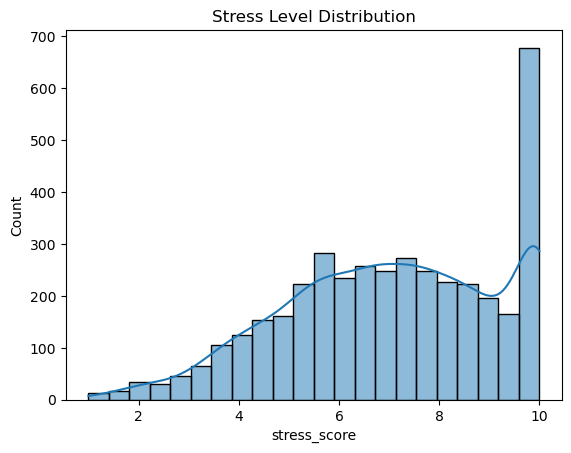

In [7]:
plt.figure()
sns.histplot(df['stress_score'], kde=True)
plt.title("Stress Level Distribution")
plt.show()

# 2. Box Plot

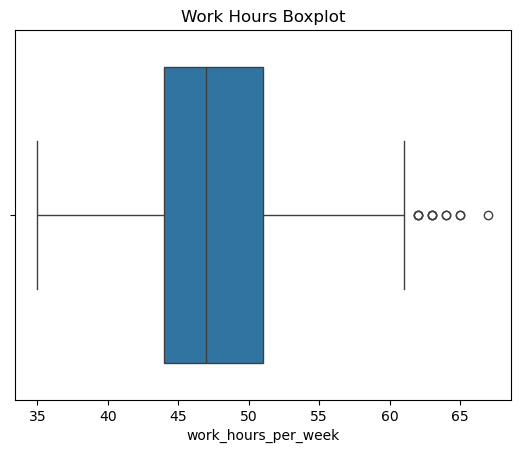

In [8]:
plt.figure()
sns.boxplot(x=df['work_hours_per_week'])
plt.title("Work Hours Boxplot")
plt.show()

# 3. Count Plot (Bar Chart for Categorical Data)

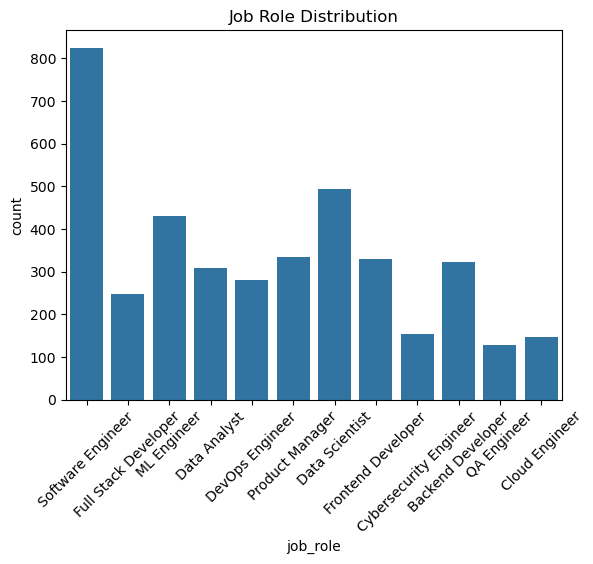

In [9]:
plt.figure()
sns.countplot(x=df['job_role'])
plt.xticks(rotation=45)
plt.title("Job Role Distribution")
plt.show()

# 4. Scatter Plot

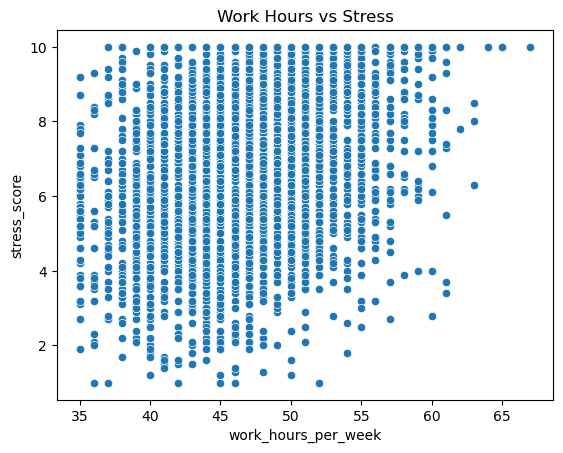

In [10]:
plt.figure()
sns.scatterplot(x='work_hours_per_week', y='stress_score', data=df)
plt.title("Work Hours vs Stress")
plt.show()

# Feature Correlation Matrix

In [11]:
# Feature correlation
print("\n4. Feature Correlation with Price:")
correlations = df[numerical_cols].corr()['burnout_score'].sort_values(ascending=False)
print(correlations)


4. Feature Correlation with Price:
burnout_score                  1.000000
stress_score                   0.850516
phq9_score                     0.714175
gad7_score                     0.706397
work_hours_per_week            0.464710
meetings_per_day               0.461418
job_change_intention           0.247979
seeks_mental_health_support    0.189299
deadline_pressure_score        0.142540
salary_usd                     0.124469
job_satisfaction_score         0.063353
ai_tools_daily                 0.020788
work_life_balance_score        0.003503
years_experience              -0.003888
age                           -0.006905
team_size                     -0.008779
years_at_company              -0.024061
therapy_access                -0.064426
autonomy_score                -0.067891
uses_therapy                  -0.076597
manager_support_score         -0.164591
exercise_days_per_week        -0.202036
social_support_score          -0.215872
vacation_days_taken           -0.295129
slee

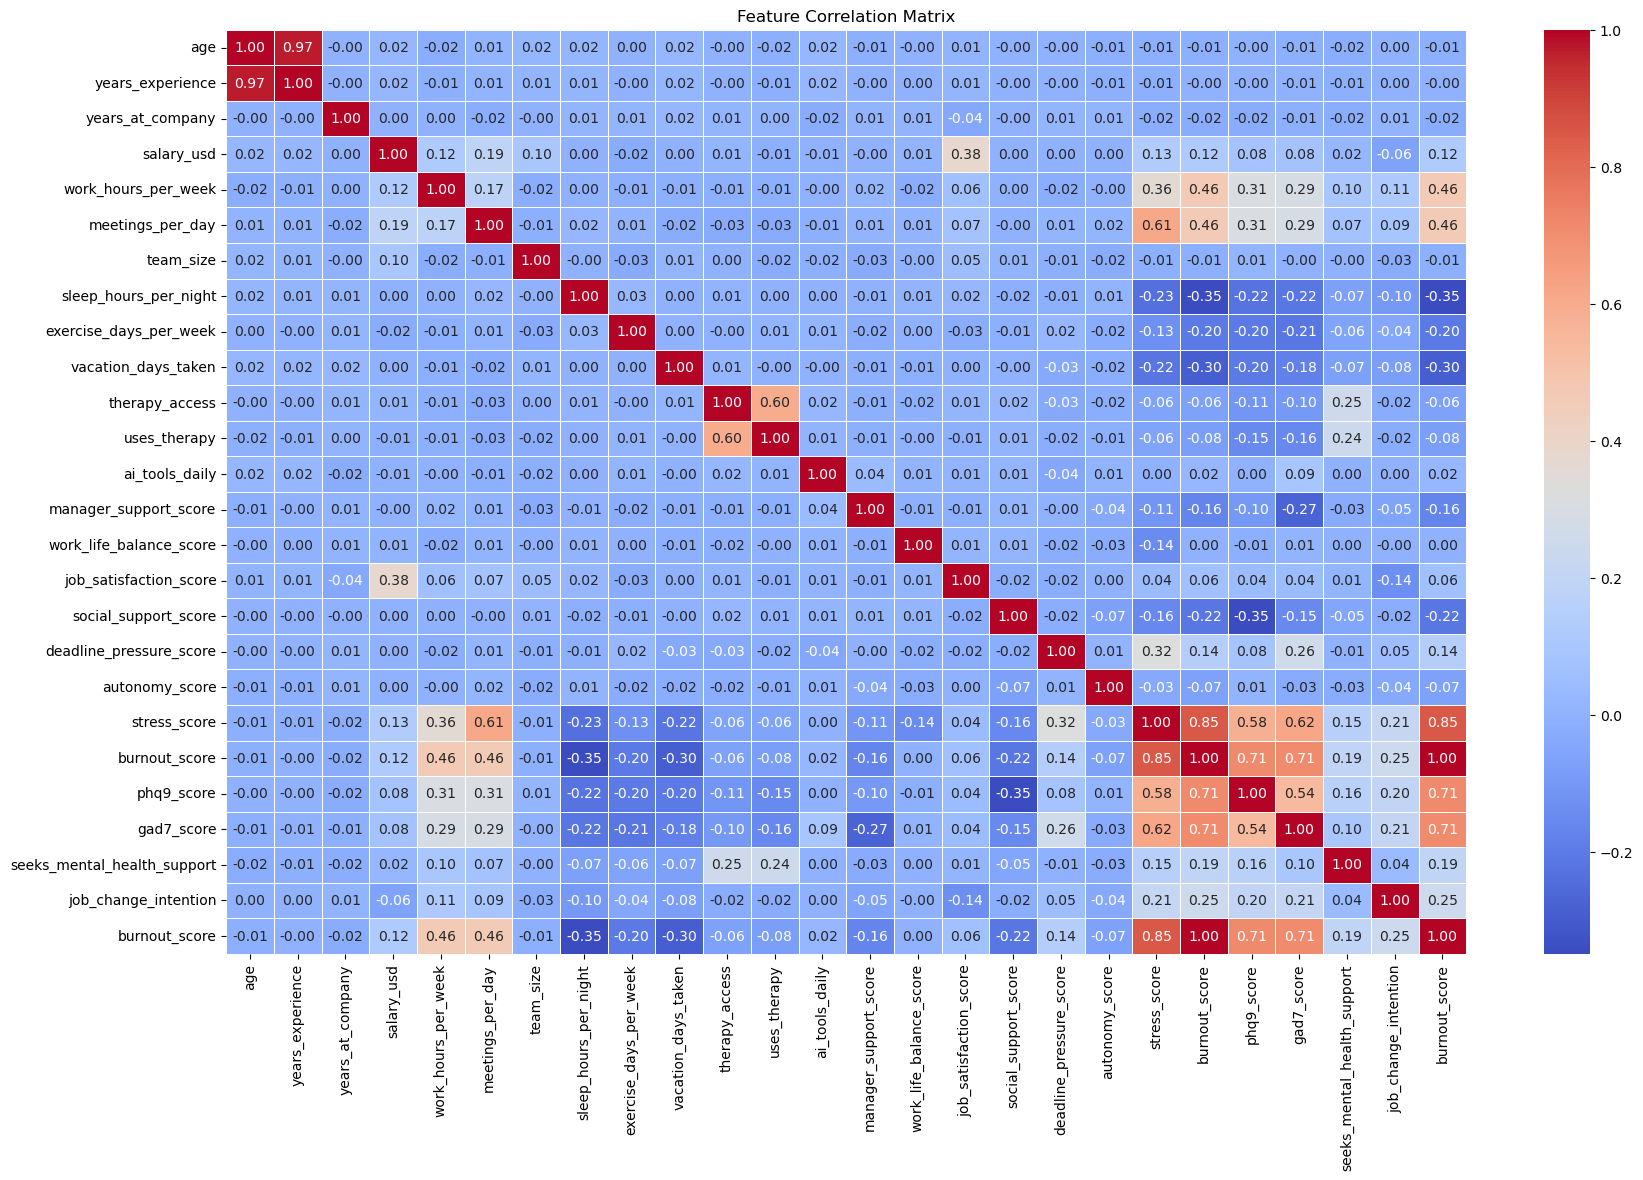

In [12]:
numerical_cols = df.select_dtypes(include=[np.number])
burnout= pd.Series(df['burnout_score'], name='burnout_score')
correlation_matrix = pd.concat([numerical_cols,burnout], axis=1).corr()
plt.figure(figsize=(20, 12))
correlation_matrix = pd.concat([numerical_cols, burnout], axis=1).corr()

# Visualize the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Preprocessing

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          4000 non-null   int64  
 1   gender                       4000 non-null   str    
 2   country                      4000 non-null   str    
 3   job_role                     4000 non-null   str    
 4   seniority_level              4000 non-null   str    
 5   years_experience             4000 non-null   int64  
 6   years_at_company             4000 non-null   float64
 7   company_size                 4000 non-null   str    
 8   industry                     4000 non-null   str    
 9   work_mode                    4000 non-null   str    
 10  salary_usd                   4000 non-null   int64  
 11  work_hours_per_week          4000 non-null   int64  
 12  meetings_per_day             4000 non-null   float64
 13  team_size                    

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Total missing values in the dataset

In [15]:
# Missing values per column and its count

print('Missing values in each column:')
print(df.isnull().sum())
print('The sum of Missing values :')
print(df.isnull().sum().sum())

Missing values in each column:
age                            0
gender                         0
country                        0
job_role                       0
seniority_level                0
years_experience               0
years_at_company               0
company_size                   0
industry                       0
work_mode                      0
salary_usd                     0
work_hours_per_week            0
meetings_per_day               0
team_size                      0
sleep_hours_per_night          0
exercise_days_per_week         0
vacation_days_taken            0
therapy_access                 0
uses_therapy                   0
ai_tools_daily                 0
manager_support_score          0
work_life_balance_score        0
job_satisfaction_score         0
social_support_score           0
deadline_pressure_score        0
autonomy_score                 0
stress_score                   0
burnout_score                  0
phq9_score                     0
gad7_score  

# Outlier Detection Using IQR Method

In [16]:
print("Detecting outliers in Features Before clipping using IQR method")
# Select numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns
total_outliers=0
for col in num_cols:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()
    total_outliers += outliers_count
    print(f"the number of Outliers in {col}: {outliers_count}")
print(f"Total number of outliers in all features: {total_outliers}")

Detecting outliers in Features Before clipping using IQR method
the number of Outliers in age: 0
the number of Outliers in years_experience: 0
the number of Outliers in years_at_company: 0
the number of Outliers in salary_usd: 0
the number of Outliers in work_hours_per_week: 0
the number of Outliers in meetings_per_day: 0
the number of Outliers in team_size: 0
the number of Outliers in sleep_hours_per_night: 0
the number of Outliers in exercise_days_per_week: 0
the number of Outliers in vacation_days_taken: 0
the number of Outliers in therapy_access: 0
the number of Outliers in uses_therapy: 0
the number of Outliers in ai_tools_daily: 0
the number of Outliers in manager_support_score: 0
the number of Outliers in work_life_balance_score: 0
the number of Outliers in job_satisfaction_score: 0
the number of Outliers in social_support_score: 0
the number of Outliers in deadline_pressure_score: 0
the number of Outliers in autonomy_score: 0
the number of Outliers in stress_score: 0
the number

# Encoding for Categorical Features

A combined encoding approach was used to handle categorical features efficiently.

- Binary categorical features were encoded using **Ordinal Encoding**.
- Features with more than two categories were encoded using **One-Hot Encoding**.

The encoded features were merged, and original categorical columns were removed.  
This approach reduces dimensionality and prepares the data for feature selection and clustering.


In [17]:
df_encoded = df.copy()

# Binary columns
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]
encoder_bin = OrdinalEncoder()
df_encoded[binary_cols] = encoder_bin.fit_transform(df[binary_cols])

# One-hot columns
onehot_cols = [col for col in categorical_cols if df[col].nunique() > 2]
encoder_ohe = OneHotEncoder( sparse_output=False, handle_unknown='ignore',min_frequency=5)

ohe_data = encoder_ohe.fit_transform(df[onehot_cols])
ohe_df = pd.DataFrame(
    ohe_data,
    columns=encoder_ohe.get_feature_names_out(onehot_cols)
)

# Data integration
df_encoded = pd.concat(
    [df_encoded.drop(columns=onehot_cols), ohe_df],
    axis=1
)
df=df_encoded.copy()

In [18]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 75 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              4000 non-null   int64  
 1   years_experience                 4000 non-null   int64  
 2   years_at_company                 4000 non-null   float64
 3   salary_usd                       4000 non-null   int64  
 4   work_hours_per_week              4000 non-null   int64  
 5   meetings_per_day                 4000 non-null   float64
 6   team_size                        4000 non-null   int64  
 7   sleep_hours_per_night            4000 non-null   float64
 8   exercise_days_per_week           4000 non-null   int64  
 9   vacation_days_taken              4000 non-null   int64  
 10  therapy_access                   4000 non-null   int64  
 11  uses_therapy                     4000 non-null   int64  
 12  ai_tools_daily                 

,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,vacation_days_taken,...,industry_E-commerce,industry_Enterprise Software,industry_Fintech,industry_Gaming,industry_Healthcare Tech,industry_SaaS / Cloud,industry_Social Media / AdTech,work_mode_Hybrid,work_mode_On-site,work_mode_Remote
0,33,11,6.4,40000,55,7.3,19,6.3,0,14,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,24,0,5.7,131165,44,5.5,7,4.7,2,15,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,36,14,5.6,169180,45,6.2,27,6.0,0,14,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,38,14,1.2,147770,54,5.3,12,6.5,1,12,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,22,0,3.0,57228,49,3.9,8,7.4,2,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Why PCA Was Not Applied
At this stage, using PCA was an available option to reduce dimensionality. However, the main issue with PCA is that it does not keep the original features as they are. Instead, PCA works by combining multiple features together into new components, where each component is a linear combination of several original features. As a result, these new components no longer represent clear, individual features.

In our case, the dataset represents the employee’s lifestyle, daily habits, work environment, and surrounding factors, such as stress score, burnout score, working hours, support level, and overall life conditions. Each feature describes a different aspect of the employee’s life and contributes independently to understanding stress and burnout. These features are not necessarily correlated, nor do they describe the same type of information.

Applying PCA would mix these different lifestyle and mental health factors into shared components that are difficult to interpret. This would cause a loss of meaning, as the resulting components would not clearly explain which real-world factors are affecting the employee. Consequently, any analysis performed afterward, such as clustering or pattern discovery, could produce misleading results and insights that do not accurately reflect the employee’s real situation.
For this reason, PCA was not applied. Keeping the original features was essential to preserve interpretability and ensure that the results and insights remain realistic and meaningful


# Genetic algorithm

After deciding not to use PCA, we moved to another approach for dimensionality reduction based on feature selection. The main idea was to use a Genetic Algorithm to select the most important features or columns while preserving the original meaning of the data. This allowed us to reduce dimensionality without merging or modifying features, which is critical for maintaining data interpretability.

In [19]:
# Genetic algorithm parameters

population_size= 20
generations = 20
MUTATION_RATE = 0.1
print("\nGenetic algorithm parameters:")
print("Population:", population_size)
print("Mutation probability:", MUTATION_RATE)
print("Generations:", generations, "\n")



Genetic algorithm parameters:
Population: 20
Mutation probability: 0.1
Generations: 20 



In [20]:
# Data Standardization
df_raw_for_clustering = df.copy() # for hierarchical
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [21]:
# Create Individual

features = df.columns.tolist()
def create_individual():
    return [random.randint(0,1) for _ in range(len(features))]

## Fitness Function

The fitness function evaluates feature subsets in a Genetic Algorithm.

- Only selected features are used for evaluation.
- If no features are selected, the fitness score is **zero**.

### Fitness Calculation
The fitness score is based on:
- **Variance**: maximized to capture informative features.
- **Correlation penalty**: reduces redundancy by penalizing highly correlated features.

\[
Fitness Score = Variance - Correlation Penalty
\]

In [22]:
# Fitness Function

def fitness(individual):
    selected_indices = [i for i in range(len(individual)) if individual[i] == 1]

    if len(selected_indices) == 0:
        return 0

    selected_data = df.iloc[:, selected_indices]

    # 1. Variance (maximize)
    variance_score = selected_data.var().sum()

    # 2. Correlation penalty (minimize redundancy)
    corr_matrix = selected_data.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    correlation_penalty = upper_triangle.sum().sum()

    # final score
    score = variance_score - correlation_penalty

    return score

In [23]:
# Selection

def select_parent(population):
    tournament = random.sample(population, 3)
    return max(tournament, key=fitness)

In [24]:
# Crossover

def crossover(parent1, parent2):
    point = random.randint(1, len(features)-1)
    child = parent1[:point] + parent2[point:]
    return child

In [25]:
# Mutation

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
         chromosome[i] = 1 - chromosome[i]
    return chromosome

In [26]:
# Genetic Algorithm

def genetic_algorithm():
    population = [create_individual() for _ in range(population_size)]

    for generation in range(generations):
        population = sorted(population, key=fitness, reverse=True)

        best = population[0]
        print(f"Generation {generation+1} Best Fitness:", fitness(best))

        new_population = []

        for _ in range(population_size):
            parent1 = select_parent(population)
            parent2 = select_parent(population)

            child = crossover(parent1, parent2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

    best_individual = max(population, key=fitness)
    return best_individual

In [27]:
best_individual = genetic_algorithm()

Generation 1 Best Fitness: 18.732738599468068
Generation 2 Best Fitness: 20.510827812813822
Generation 3 Best Fitness: 21.339994595907548
Generation 4 Best Fitness: 21.23160507118739
Generation 5 Best Fitness: 21.179651359136358
Generation 6 Best Fitness: 22.903400930634735
Generation 7 Best Fitness: 22.981218241358125
Generation 8 Best Fitness: 23.242094893937026
Generation 9 Best Fitness: 24.089635703770448
Generation 10 Best Fitness: 23.35872115250005
Generation 11 Best Fitness: 23.689046414654964
Generation 12 Best Fitness: 23.75288823838326
Generation 13 Best Fitness: 23.30768874463449
Generation 14 Best Fitness: 23.313274413105837
Generation 15 Best Fitness: 22.941004031354353
Generation 16 Best Fitness: 23.7550096461382
Generation 17 Best Fitness: 23.775223881111284
Generation 18 Best Fitness: 23.232093854609765
Generation 19 Best Fitness: 23.972030463117747
Generation 20 Best Fitness: 22.34688168954014


In [28]:
# Selecte Features

best_features = [
    features[i] for i in range(len(best_individual)) if best_individual[i] == 1
]

print("Selected Features:")
print(best_features)

print("Number of Features:", len(best_features))

Selected Features:
['age', 'years_at_company', 'team_size', 'sleep_hours_per_night', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'work_life_balance_score', 'job_satisfaction_score', 'deadline_pressure_score', 'gender_Female', 'gender_Prefer not to say', 'country_Australia', 'country_Brazil', 'country_France', 'country_Germany', 'country_India', 'country_Netherlands', 'country_Singapore', 'country_UK', 'job_role_Backend Developer', 'job_role_Data Analyst', 'job_role_Data Scientist', 'job_role_DevOps Engineer', 'job_role_Full Stack Developer', 'job_role_QA Engineer', 'job_role_Software Engineer', 'seniority_level_Manager', 'seniority_level_Mid', 'seniority_level_Principal', 'seniority_level_Senior', 'company_size_Large (1001-5000)', 'company_size_Small (51-200)', 'industry_AI / ML Startup', 'industry_Enterprise Software', 'industry_Fintech', 'industry_Gaming', 'industry_Social Media / AdTech', 'work_mode_On-site']
Number of Features: 39


## Best Features vs Baseline Feature Set
The baseline approach was based on using the full feature set, which originally included 75 features after preprocessing and encoding. Although this approach keeps all the data, it introduces high dimensionality and a lot of redundancy, especially because of the large number of encoded categorical columns. This makes the data harder to interpret and can negatively affect distance-based models such as clustering.

On the other hand, the Genetic Algorithm was able to select a reduced and more focused subset of 39 features. This reduction helped remove less informative and redundant columns while keeping the most meaningful ones that describe employee lifestyle, work conditions, stress, and burnout. Compared to the baseline, the selected feature set gives a cleaner and more interpretable representation of the data, which improves both efficiency and analysis quality.

The final selected features include: age, years_at_company, team_size, sleep_hours_per_night, therapy_access, uses_therapy, ai_tools_daily, work_life_balance_score, job_satisfaction_score, deadline_pressure_score, gender_Female, gender_Prefer not to say, country_Australia, country_Brazil, country_France, country_Germany, country_India, country_Netherlands, country_Singapore, country_UK, job_role_Backend Developer, job_role_Data Analyst, job_role_Data Scientist, job_role_DevOps Engineer, job_role_Full Stack Developer, job_role_QA Engineer, job_role_Software Engineer, seniority_level_Manager, seniority_level_Mid, seniority_level_Principal, seniority_level_Senior, company_size_Large (1001–5000), company_size_Small (51–200), industry_AI / ML Startup, industry_Enterprise Software, industry_Fintech, industry_Gaming, industry_Social Media / AdTech, and work_mode_On-site.


In [29]:
print(df[best_features].nunique())

age                                32
years_at_company                  140
team_size                          58
sleep_hours_per_night              67
therapy_access                      2
uses_therapy                        2
ai_tools_daily                      2
work_life_balance_score            91
job_satisfaction_score             91
deadline_pressure_score            90
gender_Female                       2
gender_Prefer not to say            2
country_Australia                   2
country_Brazil                      2
country_France                      2
country_Germany                     2
country_India                       2
country_Netherlands                 2
country_Singapore                   2
country_UK                          2
job_role_Backend Developer          2
job_role_Data Analyst               2
job_role_Data Scientist             2
job_role_DevOps Engineer            2
job_role_Full Stack Developer       2
job_role_QA Engineer                2
job_role_Sof

## Feature Preparation for Clustering

Before applying clustering models, a feature preparation step was performed.

- Numerical features selected by the Genetic Algorithm were extracted into `non_ohe_features`, as they are suitable for distance-based clustering.
- Additional `domain_features` were manually added based on domain knowledge (e.g., work-related and lifestyle factors).
- Both feature sets were combined into `clustering_features`.
- A validation step ensured that all selected features exist in the dataset.

This process resulted in a clean and meaningful feature set prepared specifically for clustering.

In [30]:
# Feature Selection for Clustering

non_ohe_features = [
    i for i in best_features
    if i in numerical_cols
]

domain_features = [
    'years_experience',
    'work_hours_per_week',
    'manager_support_score',
    'vacation_days_taken'
]

clustering_features = list(set(non_ohe_features + domain_features))

clustering_features = [
    i for i in clustering_features
    if i in df.columns
]

print(clustering_features)

['work_life_balance_score', 'years_at_company', 'uses_therapy', 'deadline_pressure_score', 'manager_support_score', 'ai_tools_daily', 'team_size', 'sleep_hours_per_night', 'vacation_days_taken', 'therapy_access', 'work_hours_per_week', 'age', 'years_experience', 'job_satisfaction_score']


#  k-medoid clustering

In [31]:
# Preparing Data for K-Medoids Clustering

data_for_kmedoids = df_raw_for_clustering[non_ohe_features]
X = data_for_kmedoids.to_numpy()

In [32]:
# Selecting Optimal Number of Clusters (K-Medoids)

sil_scores = []
inertias = []
K_range = range(2, 11)

print(">>> Searching for best k...\n")

for k in K_range:
    model = KMedoids(
        n_clusters=k,
        metric='manhattan',
        init='k-medoids++',
        random_state=42
    ).fit(X)

    labels = model.labels_

    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

    inertias.append(model.inertia_)

    print(f"k={k} → Silhouette={sil:.4f} | Inertia={model.inertia_:.2f}")

# Best k
best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"\n>>> Best k (Silhouette) = {best_k}\n")

>>> Searching for best k...



c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=2 → Silhouette=0.3755 | Inertia=75605.30


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=3 → Silhouette=0.2929 | Inertia=70012.90


...

k=8 → Silhouette=0.1943 | Inertia=55301.20


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=9 → Silhouette=0.1832 | Inertia=53479.50


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=10 → Silhouette=0.1692 | Inertia=52740.20

>>> Best k (Silhouette) = 2



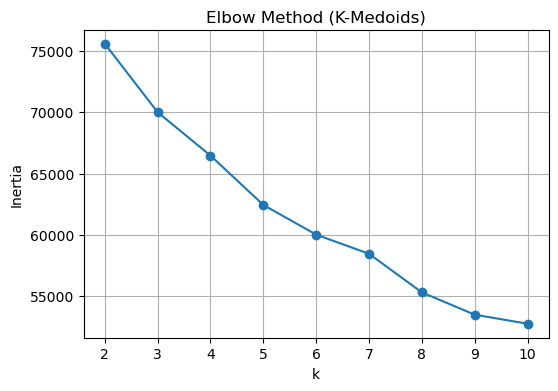

In [33]:
# Elbow Plot

plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker='o')
plt.title("Elbow Method (K-Medoids)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid()
plt.show()

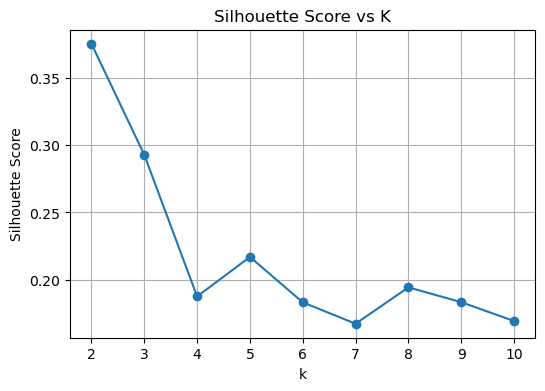

In [34]:
# Silhouette Plot

plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

In [35]:
# Final Model

final_model = KMedoids(
    n_clusters=best_k,
    metric='manhattan',
    init='k-medoids++',
    random_state=42
)

labels = final_model.fit_predict(X)

data_with_clusters = data_for_kmedoids.copy()
data_with_clusters['cluster'] = labels

c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


C:\Users\Dell\AppData\Local\Temp\ipykernel_9040\1152053179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_with_clusters['cluster'], palette="Set2")


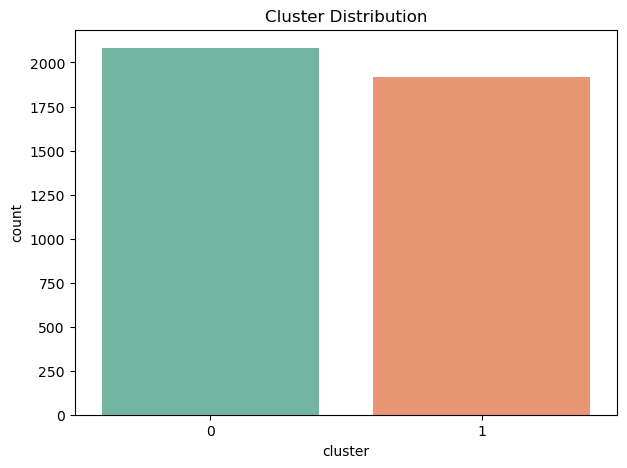

In [36]:
# Cluster Distribution

plt.figure(figsize=(7,5))
sns.countplot(x=data_with_clusters['cluster'], palette="Set2")
plt.title("Cluster Distribution")
plt.show()


=== Cluster Summary (Means) ===
           age  years_at_company  team_size  sleep_hours_per_night  \
cluster                                                              
0        30.89              2.45       8.58                   6.08   
1        31.55              2.51      28.61                   6.10   

         therapy_access  uses_therapy  ai_tools_daily  \
cluster                                                 
0                  0.36          0.18            0.74   
1                  0.33          0.13            0.72   

         work_life_balance_score  job_satisfaction_score  \
cluster                                                    
0                           5.37                    4.70   
1                           5.40                    4.92   

         deadline_pressure_score  
cluster                           
0                           6.40  
1                           6.45  


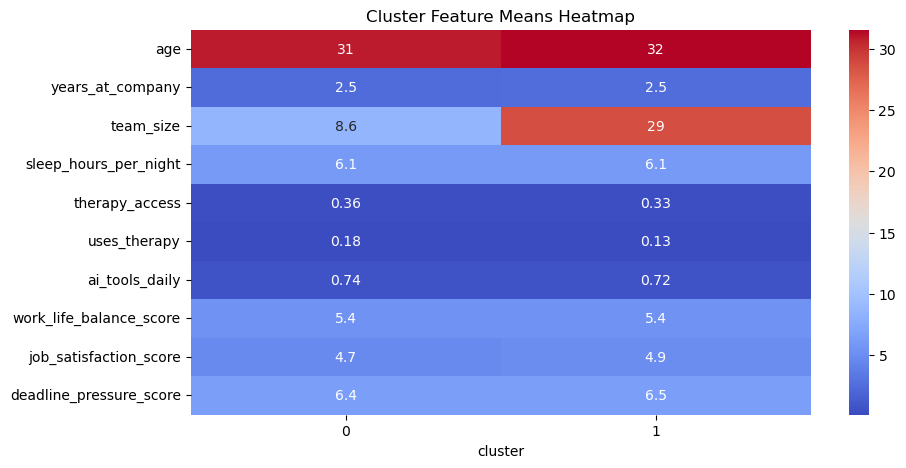

In [37]:
# Cluster Summary and Heatmap

cluster_summary = data_with_clusters.groupby('cluster').mean().round(2)

print("\n=== Cluster Summary (Means) ===")
print(cluster_summary)

plt.figure(figsize=(10,5))
sns.heatmap(cluster_summary.T, annot=True, cmap="coolwarm")
plt.title("Cluster Feature Means Heatmap")
plt.show()

In [38]:
# Medoids

print("\nMedoid indices:", final_model.medoid_indices_)
print("\nMedoids:")
print(data_for_kmedoids.iloc[final_model.medoid_indices_])


Medoid indices: [3669 3114]

Medoids:
      age  years_at_company  team_size  sleep_hours_per_night  therapy_access  \
3669   32               1.0          8                    6.0               1   
3114   33               1.5         26                    6.6               0   

      uses_therapy  ai_tools_daily  work_life_balance_score  \
3669             0               1                      5.8   
3114             0               1                      6.3   

      job_satisfaction_score  deadline_pressure_score  
3669                     4.9                      6.0  
3114                     5.8                      6.3  


## Hierarchical clustering

In [39]:
# Data Preparation for Clustering

X_full = df_raw_for_clustering.iloc[:4000].copy()
print(f"Shape for clustering: {X_full.shape}")
print(f"Number of features: {X_full.shape[1]}")

numeric_cols = X_full.select_dtypes(include=[np.number]).columns
X_full = X_full[numeric_cols]
print(f"Numerical features only: {X_full.shape[1]}")

Shape for clustering: (4000, 75)
Number of features: 75
Numerical features only: 75


In [40]:
# Selecting Optimal Number of Clusters (k)

silhouette_scores_full = []
for k in range(2, 8):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_full)
    score = silhouette_score(X_full, labels)
    silhouette_scores_full.append((k, score))
    print(f"k={k} -> score={score:.4f}")

best_k_full = max(silhouette_scores_full, key=lambda x: x[1])[0]
print(f"\nBest k selected: {best_k_full}")


k=2 -> score=0.5385
k=3 -> score=0.5946
k=4 -> score=0.5783
k=5 -> score=0.5988
k=6 -> score=0.5787
k=7 -> score=0.5785

Best k selected: 5


In [41]:
# Comparing Linkage Methods

hc_ward_full = AgglomerativeClustering(n_clusters=best_k_full, linkage='ward')
labels_ward_full = hc_ward_full.fit_predict(X_full)

hc_complete_full = AgglomerativeClustering(n_clusters=best_k_full, linkage='complete')
labels_complete_full = hc_complete_full.fit_predict(X_full)

hc_average_full = AgglomerativeClustering(n_clusters=best_k_full, linkage='average')
labels_average_full = hc_average_full.fit_predict(X_full)

ward_score_full = silhouette_score(X_full, labels_ward_full)
complete_score_full = silhouette_score(X_full, labels_complete_full)
average_score_full = silhouette_score(X_full, labels_average_full)

print("Ward:", ward_score_full)
print("Complete:", complete_score_full)
print("Average:", average_score_full)

scores_full = {"Ward": ward_score_full, "Complete": complete_score_full, "Average": average_score_full}
best_method_full = max(scores_full, key=scores_full.get)
print(f"\nBest Method: {best_method_full}")


Ward: 0.5988491571922332
Complete: 0.5457970406337024
Average: 0.5861060871424338

Best Method: Ward


In [42]:
# Selecting Final Clustering Model

if best_method_full == "Ward":
    labels_final_full = labels_ward_full
elif best_method_full == "Complete":
    labels_final_full = labels_complete_full
else:
    labels_final_full = labels_average_full

print("\nCluster distribution:")
print(pd.Series(labels_final_full).value_counts())


Cluster distribution:
0    1558
2    1020
3     728
1     567
4     127
Name: count, dtype: int64


In [43]:
# Cluster Profiling

important_cols = ['burnout_score', 'stress_score', 'sleep_hours_per_night',
                  'work_hours_per_week', 'manager_support_score',
                  'work_life_balance_score', 'autonomy_score']

available_cols = [col for col in important_cols if col in X_full.columns]

X_full_df = pd.DataFrame(X_full)
X_full_df['cluster'] = labels_final_full
cluster_profile_full = X_full_df.groupby('cluster')[available_cols].mean()

print("\n===== Cluster Profiles =====")
print(cluster_profile_full.round(2))


===== Cluster Profiles =====
         burnout_score  stress_score  sleep_hours_per_night  \
cluster                                                       
0                 5.30          6.96                   6.09   
1                 6.15          7.63                   6.09   
2                 4.88          6.64                   6.09   
3                 5.61          7.24                   6.11   
4                 6.50          7.97                   6.13   

         work_hours_per_week  manager_support_score  work_life_balance_score  \
cluster                                                                        
0                      47.01                   5.78                     5.34   
1                      48.60                   5.69                     5.41   
2                      46.04                   5.80                     5.45   
3                      47.47                   5.75                     5.40   
4                      49.52                   5

### Visualization of Clusters

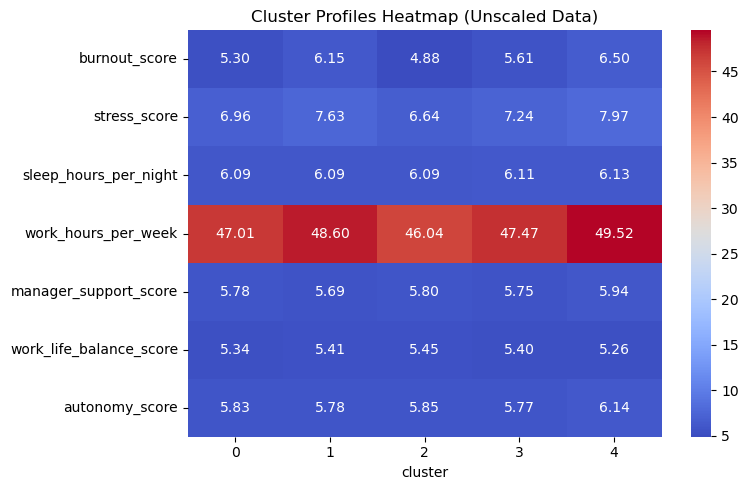

In [44]:
# Heatmap (Unscaled Data)

plt.figure(figsize=(8, 5))
sns.heatmap(cluster_profile_full.T, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cluster Profiles Heatmap (Unscaled Data)")
plt.tight_layout()
plt.show()

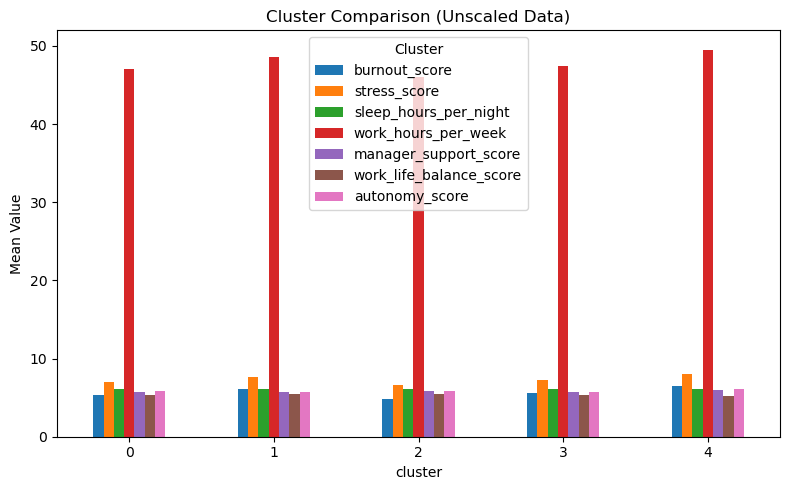

In [45]:
# Cluster Comparison (Unscaled Data)

cluster_profile_full.plot(kind='bar', figsize=(8, 5))
plt.title("Cluster Comparison (Unscaled Data)")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# Fuzzy logic

In [46]:
# Define fuzzy variables
sleep = ctrl.Antecedent(np.arange(0, 11, 1), 'sleep_hours_per_night')
work = ctrl.Antecedent(np.arange(0, 101, 1), 'work_hours_per_week')
stress = ctrl.Antecedent(np.arange(0, 11, 1), 'stress_score')
burnout = ctrl.Consequent(np.arange(0, 101, 1), 'burnout_risk_percentage')

In [47]:
# Membership functions for sleep
sleep['good'] = fuzz.trimf(sleep.universe, [6, 8, 10])      # good sleep: 6-10 hours
sleep['average'] = fuzz.trimf(sleep.universe, [4, 6, 8])    # average sleep: 4-8 hours
sleep['poor'] = fuzz.trimf(sleep.universe, [0, 3, 5])       # poor sleep: 0-5 hours

In [48]:
# Membership functions for work
work['normal'] = fuzz.trimf(work.universe, [20, 40, 50])    # normal: 20-50 hours/week
work['moderate'] = fuzz.trimf(work.universe, [35, 50, 65])  # moderate: 35-65 hours/week
work['excessive'] = fuzz.trimf(work.universe, [55, 70, 100]) # excessive: 55-100 hours/week

In [49]:
# Membership functions for pressure
stress['low'] = fuzz.trimf(stress.universe, [0, 2, 4])      # low stress: 0-4
stress['medium'] = fuzz.trimf(stress.universe, [3, 5, 7])   # medium stress: 3-7
stress['high'] = fuzz.trimf(stress.universe, [6, 8, 10])    # high stress: 6-10

In [50]:
# Membership functions for burnout
burnout['low'] = fuzz.trimf(burnout.universe, [0, 20, 40])     # low burnout
burnout['medium'] = fuzz.trimf(burnout.universe, [30, 50, 70]) # medium burnout
burnout['high'] = fuzz.trimf(burnout.universe, [60, 80, 100])  # high burnout
burnout['severe'] = fuzz.trimf(burnout.universe, [80, 95, 100]) # severe burnout

In [51]:
# Rules
rule1 = ctrl.Rule(sleep['good'] & work['normal'] & stress['low'], burnout['low'])
rule2 = ctrl.Rule(sleep['average'] & work['moderate'] & stress['medium'], burnout['medium'])
rule3 = ctrl.Rule(sleep['poor'] | work['excessive'] | stress['high'], burnout['high'])
rule4 = ctrl.Rule(sleep['poor'] & work['excessive'] & stress['high'], burnout['severe'])
rule5 = ctrl.Rule(sleep['average'] & work['moderate'] & stress['high'], burnout['high'])

In [52]:
# Control system
burnout_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
burnout_sim = ctrl.ControlSystemSimulation(burnout_ctrl)

In [53]:
# Cluster Feature Extraction
for cluster_id in cluster_profile_full.index:
    sleep_mean = cluster_profile_full.loc[cluster_id, 'sleep_hours_per_night']
    work_mean = cluster_profile_full.loc[cluster_id, 'work_hours_per_week']
    stress_mean = cluster_profile_full.loc[cluster_id, 'stress_score']
    actual_burnout = cluster_profile_full.loc[cluster_id, 'burnout_score']

In [54]:
# Model Input
burnout_sim.input['sleep_hours_per_night'] = sleep_mean
burnout_sim.input['work_hours_per_week'] = work_mean
burnout_sim.input['stress_score'] = stress_mean

In [55]:
# Compute result
burnout_sim.compute()
risk_score = burnout_sim.output['burnout_risk_percentage']

# System Implementation

```
Raw Record
    ↓  Drop useless columns
    ↓  Encode  (Binary + OneHot)
    ↓  Align columns
    ↓  Scale  (StandardScaler)
    ├──>  KNN Cluster Assignment  (Ward labels)
    └──>  Fuzzy Logic  (raw values)
              ↓
         Final Result  (Cluster + Risk Score + Recommendation)

In [56]:
def system_implementation(record,
                          encoder_bin,
                          encoder_ohe,
                          binary_cols,
                          onehot_cols,
                          scaler,
                          best_features,
                          clustering_features,
                          X_cluster,
                          labels_ward,
                          burnout_sim):

    # Convert record to DataFrame
    record_df = pd.DataFrame([record])

    # Handle missing columns BEFORE encoding
    for col in binary_cols:
        if col not in record_df.columns:
            record_df[col] = 0

    for col in onehot_cols:
        if col not in record_df.columns:
            record_df[col] = 'Unknown'

    # Encoding
    record_df[binary_cols] = encoder_bin.transform(record_df[binary_cols])
    ohe_data = encoder_ohe.transform(record_df[onehot_cols])
    ohe_df = pd.DataFrame(
        ohe_data,
        columns=encoder_ohe.get_feature_names_out(onehot_cols)
    )

    record_df = pd.concat([record_df.drop(columns=onehot_cols), ohe_df], axis=1)

    # Align with scaler (FIX)
    record_df = record_df.reindex(
       columns=scaler.feature_names_in_,
       fill_value=0
    )

    # Scaling
    record_scaled = pd.DataFrame(
      scaler.transform(record_df),
      columns=record_df.columns
    )

    # Feature Selection
    selected_record = record_scaled.copy()
    selected_features_safe = [f for f in best_features if f in selected_record.columns]
    selected_record = selected_record[selected_features_safe]

    # Clustering
    cluster_data_aligned = X_cluster.reindex(
        columns=scaler.feature_names_in_,
        fill_value=0
    )

    cluster_data_scaled = scaler.transform(cluster_data_aligned)

    cluster_df = pd.DataFrame(cluster_data_scaled, columns=scaler.feature_names_in_)
    cluster_df['cluster'] = labels_ward

    centroids = cluster_df.groupby('cluster')[clustering_features].mean()

    clustering_features_safe = [
        f for f in clustering_features if f in record_scaled.columns
    ]

    record_vec = record_scaled[scaler.feature_names_in_][clustering_features_safe].values
    centroid_vecs = centroids[clustering_features_safe].values

    distances = cdist(record_vec, centroid_vecs)

    assigned_cluster = int(np.argmin(distances[0]))

    # Fuzzy System
    burnout_sim.input['sleep_hours_per_night'] = record.get('sleep_hours_per_night', 0)
    burnout_sim.input['work_hours_per_week'] = record.get('work_hours_per_week', 0)
    burnout_sim.input['stress_score'] = record.get('stress_score', 0)
    burnout_sim.compute()
    burnout = burnout_sim.output['burnout_risk_percentage']

    # Output
    return {
        "cluster": assigned_cluster,
        "burnout_risk": float(burnout),
        "selected_features_used": selected_features_safe
    }

## Testing the System

In [57]:
record1 = {
    'age': 29,
    'gender': 'Male',
    'country': 'USA',
    'job_role': 'Software Engineer',
    'seniority_level': 'Mid',
    'years_experience': 5,
    'years_at_company': 2,
    'company_size': 'Large',
    'industry': 'Tech',
    'work_mode': 'Remote',
    'salary_usd': 90000,
    'work_hours_per_week': 65,
    'meetings_per_day': 6,
    'team_size': 10,
    'sleep_hours_per_night': 4.5,
    'exercise_days_per_week': 0,
    'vacation_days_taken': 2,
    'therapy_access': 0,
    'uses_therapy': 0,
    'ai_tools_daily': 1,
    'manager_support_score': 3,
    'work_life_balance_score': 2,
    'job_satisfaction_score': 4,
    'social_support_score': 3,
    'deadline_pressure_score': 9,
    'autonomy_score': 4,
    'stress_score': 9,
    'burnout_score': 80,
    'phq9_score': 15,
    'gad7_score': 14,
    'seeks_mental_health_support': 0,
    'job_change_intention': 1,
}

result1 = system_implementation(
    record1,
    encoder_bin,
    encoder_ohe,
    binary_cols,
    onehot_cols,
    scaler,
    best_features,
    clustering_features,
    X_full,
    labels_ward_full,
    burnout_sim
)

print(result1)

{'cluster': 1, 'burnout_risk': 80.46027592768797, 'selected_features_used': ['age', 'years_at_company', 'team_size', 'sleep_hours_per_night', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'work_life_balance_score', 'job_satisfaction_score', 'deadline_pressure_score', 'gender_Female', 'gender_Prefer not to say', 'country_Australia', 'country_Brazil', 'country_France', 'country_Germany', 'country_India', 'country_Netherlands', 'country_Singapore', 'country_UK', 'job_role_Backend Developer', 'job_role_Data Analyst', 'job_role_Data Scientist', 'job_role_DevOps Engineer', 'job_role_Full Stack Developer', 'job_role_QA Engineer', 'job_role_Software Engineer', 'seniority_level_Manager', 'seniority_level_Mid', 'seniority_level_Principal', 'seniority_level_Senior', 'company_size_Large (1001-5000)', 'company_size_Small (51-200)', 'industry_AI / ML Startup', 'industry_Enterprise Software', 'industry_Fintech', 'industry_Gaming', 'industry_Social Media / AdTech', 'work_mode_On-site']}


In [58]:
record2 = {
    'age': 35,
    'gender': 'Female',
    'country': 'UK',
    'job_role': 'Data Analyst',
    'seniority_level': 'Senior',
    'years_experience': 10,
    'years_at_company': 4,
    'company_size': 'Medium',
    'industry': 'Finance',
    'work_mode': 'Hybrid',
    'salary_usd': 85000,
    'work_hours_per_week': 45,
    'meetings_per_day': 3,
    'team_size': 6,
    'sleep_hours_per_night': 6.5,
    'exercise_days_per_week': 2,
    'vacation_days_taken': 10,
    'therapy_access': 1,
    'uses_therapy': 0,
    'ai_tools_daily': 1,
    'manager_support_score': 6,
    'work_life_balance_score': 5,
    'job_satisfaction_score': 6,
    'social_support_score': 6,
    'deadline_pressure_score': 6,
    'autonomy_score': 6,
    'stress_score': 6,
    'burnout_score': 50,
    'phq9_score': 8,
    'gad7_score': 7,
    'seeks_mental_health_support': 1,
    'job_change_intention': 0,
}

result2 = system_implementation(
    record2,
    encoder_bin,
    encoder_ohe,
    binary_cols,
    onehot_cols,
    scaler,
    best_features,
    clustering_features,
    X_full,
    labels_ward_full,
    burnout_sim
)

print(result2)

{'cluster': 3, 'burnout_risk': 50.0, 'selected_features_used': ['age', 'years_at_company', 'team_size', 'sleep_hours_per_night', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'work_life_balance_score', 'job_satisfaction_score', 'deadline_pressure_score', 'gender_Female', 'gender_Prefer not to say', 'country_Australia', 'country_Brazil', 'country_France', 'country_Germany', 'country_India', 'country_Netherlands', 'country_Singapore', 'country_UK', 'job_role_Backend Developer', 'job_role_Data Analyst', 'job_role_Data Scientist', 'job_role_DevOps Engineer', 'job_role_Full Stack Developer', 'job_role_QA Engineer', 'job_role_Software Engineer', 'seniority_level_Manager', 'seniority_level_Mid', 'seniority_level_Principal', 'seniority_level_Senior', 'company_size_Large (1001-5000)', 'company_size_Small (51-200)', 'industry_AI / ML Startup', 'industry_Enterprise Software', 'industry_Fintech', 'industry_Gaming', 'industry_Social Media / AdTech', 'work_mode_On-site']}


In [59]:
record3 = {
    "age": 30,
    "gender": "female",
    "country": "Egypt",
    "job_role": "Data Scientist",
    "seniority_level": "mid",
    "years_experience": 5,
    "years_at_company": 4,
    "company_size": "medium",
    "industry": "tech",
    "work_mode": "hybrid",

    "salary_usd": 500,
    "work_hours_per_week": 70,
    "meetings_per_day": 5,
    "team_size": 8,

    "sleep_hours_per_night": 3,
    "exercise_days_per_week": 2,
    "vacation_days_taken": 0,


    "ai_tools_daily": 3,

    "manager_support_score": 2,
    "work_life_balance_score": 4,
    "job_satisfaction_score": 3,
    "social_support_score": 1,

    "deadline_pressure_score": 5
}
result3 = system_implementation(
    record3,
    encoder_bin,
    encoder_ohe,
    binary_cols,
    onehot_cols,
    scaler,
    best_features,
    clustering_features,
    X_full,
    labels_ward_full,
    burnout_sim
)

print(result3)

{'cluster': 4, 'burnout_risk': 80.00000000000006, 'selected_features_used': ['age', 'years_at_company', 'team_size', 'sleep_hours_per_night', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'work_life_balance_score', 'job_satisfaction_score', 'deadline_pressure_score', 'gender_Female', 'gender_Prefer not to say', 'country_Australia', 'country_Brazil', 'country_France', 'country_Germany', 'country_India', 'country_Netherlands', 'country_Singapore', 'country_UK', 'job_role_Backend Developer', 'job_role_Data Analyst', 'job_role_Data Scientist', 'job_role_DevOps Engineer', 'job_role_Full Stack Developer', 'job_role_QA Engineer', 'job_role_Software Engineer', 'seniority_level_Manager', 'seniority_level_Mid', 'seniority_level_Principal', 'seniority_level_Senior', 'company_size_Large (1001-5000)', 'company_size_Small (51-200)', 'industry_AI / ML Startup', 'industry_Enterprise Software', 'industry_Fintech', 'industry_Gaming', 'industry_Social Media / AdTech', 'work_mode_On-site']}
